# Netflix Movies & TV Shows Content Analysis

## 1. Introduction

This project analyzes Netflix Movies and TV Shows using exploratory data analysis, visualization, feature engineering, and machine learning to identify useful content trends and patterns.

## 2. Importing Libraries

[import pandas as pd]
[other imports you have]

In [3]:
import pandas as pd

## 3. Loading the Dataset

In [4]:
df = pd.read_csv("netflix_titles.csv")

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 4. Understanding the Dataset

### 4.1 Dataset Shape

In [6]:
df.shape

(8807, 12)

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("netflix_titles.csv")

### 4.2 Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### 4.3 Statistical Summary

In [10]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


### 4.4 Dataset Columns

In [11]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

## 5. Data Cleaning

### 5.1 Missing Values

In [12]:
df.isnull().sum() ##Check missing values

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [13]:
(df.isnull().sum() / len(df) * 100).round(2) ##Check missing-value percentage

show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64

In [14]:
df['director'] = df['director'].fillna('unknown')
df['cast'] = df['cast'].fillna('unknown')
df['country'] = df['country'].fillna('unknown')
df['rating'] = df['rating'].fillna('unknown')
df['duration'] = df['duration'].fillna('Unknown') ##Fill missing text/categorical values

In [15]:
raw_date = pd.read_csv("netflix_titles.csv")["date_added"]

df["date_added"] = pd.to_datetime(
    raw_date,
    format="mixed",
    errors="coerce"
) ## Handle date_added

In [16]:
df.isnull().sum ## Verifies  the result

<bound method DataFrame.sum of       show_id   type  title  director   cast  country  date_added  \
0       False  False  False     False  False    False       False   
1       False  False  False     False  False    False       False   
2       False  False  False     False  False    False       False   
3       False  False  False     False  False    False       False   
4       False  False  False     False  False    False       False   
...       ...    ...    ...       ...    ...      ...         ...   
8802    False  False  False     False  False    False       False   
8803    False  False  False     False  False    False       False   
8804    False  False  False     False  False    False       False   
8805    False  False  False     False  False    False       False   
8806    False  False  False     False  False    False       False   

      release_year  rating  duration  listed_in  description  
0            False   False     False      False        False  
1            F

### 5.2 Duplicate Values

In [17]:
df.duplicated().sum()

0

In [18]:
df.isnull().mean()*100

show_id         0.000000
type            0.000000
title           0.000000
director        0.000000
cast            0.000000
country         0.000000
date_added      0.113546
release_year    0.000000
rating          0.000000
duration        0.000000
listed_in       0.000000
description     0.000000
dtype: float64

In [19]:
df[df.isnull().any(axis=1)].head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,unknown,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaT,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,unknown,Anthony Bourdain,United States,NaT,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,unknown,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaT,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,unknown,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaT,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,unknown,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaT,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."


### 5.3 Outlier Analysis

In [20]:
df['release_year'].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

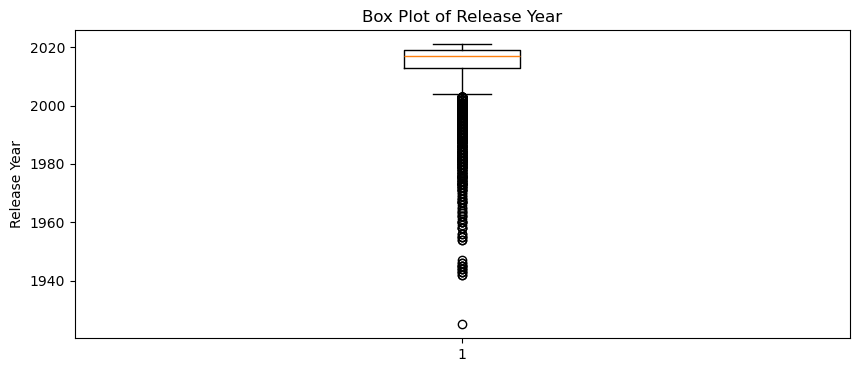

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.boxplot(df['release_year'])
plt.title('Box Plot of Release Year')
plt.ylabel('Release Year')
plt.show()

## 6. Exploratory Data Analysis

### 6.1 Movies vs TV Shows

In [22]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

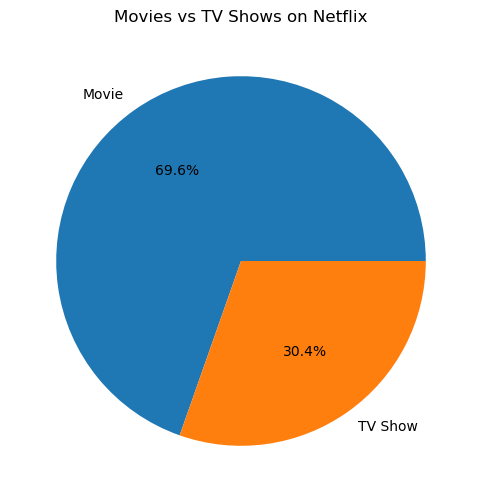

In [23]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%')
plt.title('Movies vs TV Shows on Netflix')
plt.show()

**Interpretation:**  
Movies make up the majority of the Netflix titles in the dataset, accounting for approximately 69% of the content, while TV Shows account for approximately 30%.

### 6.2 Content Added Per Year

In [24]:
df.groupby(['release_year', 'type']).size().unstack()

type,Movie,TV Show
release_year,,
1925,NaN,1.0
1942,2.0,NaN
1943,3.0,NaN
1944,3.0,NaN
1945,3.0,1.0
...,...,...
2017,767.0,265.0
2018,767.0,380.0
2019,633.0,397.0


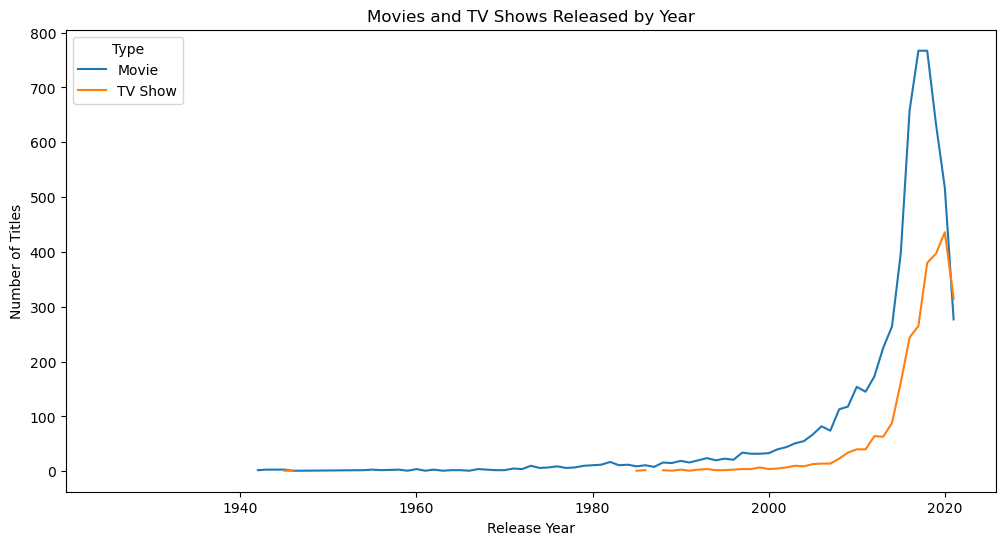

In [25]:
year_type = df.groupby(['release_year', 'type']).size().unstack()

year_type.plot(figsize=(12, 6))

plt.title('Movies and TV Shows Released by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.show()

In [26]:
df['added_year'] = df['date_added'].dt.year

In [27]:
df['added_year'].value_counts().sort_index()

added_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

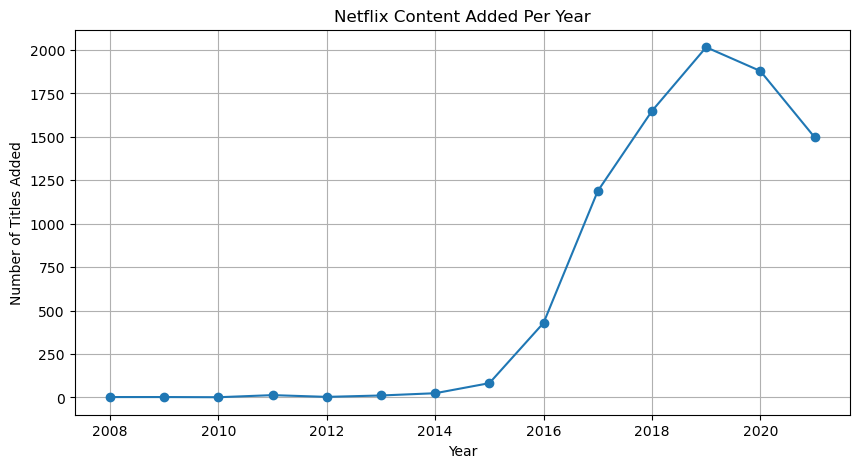

In [28]:
content_added = df['added_year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(content_added.index, content_added.values, marker='o')

plt.title('Netflix Content Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True)
plt.show()

In [29]:
country_counts = df['country'].str.split(', ').explode().value_counts()

### 6.3 Top 10 Countries

In [30]:
top_countries = country_counts.head(10)
top_countries

country
United States     3689
India             1046
unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

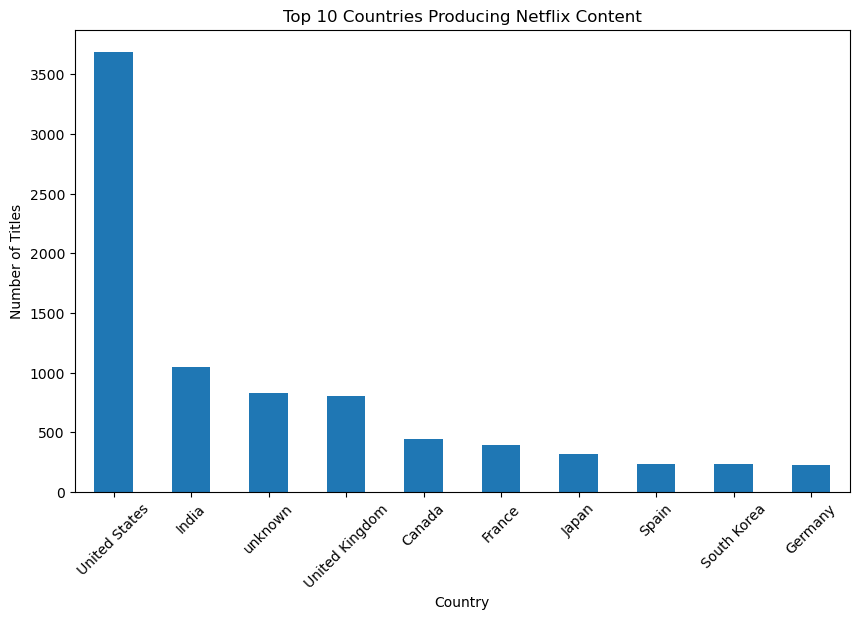

In [31]:
plt.figure(figsize=(10, 6))

top_countries.plot(kind='bar')

plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

In [32]:
top_countries

country
United States     3689
India             1046
unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

**Interpretation:**  
The United States is the leading country associated with Netflix content in the dataset. The remaining countries in the top 10 show that Netflix's content library has contributions from multiple countries around the world.

### 6.4 Genre Analysis

In [33]:
genre_counts = df['listed_in'].str.split(', ').explode().value_counts()

In [34]:
genre_counts.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

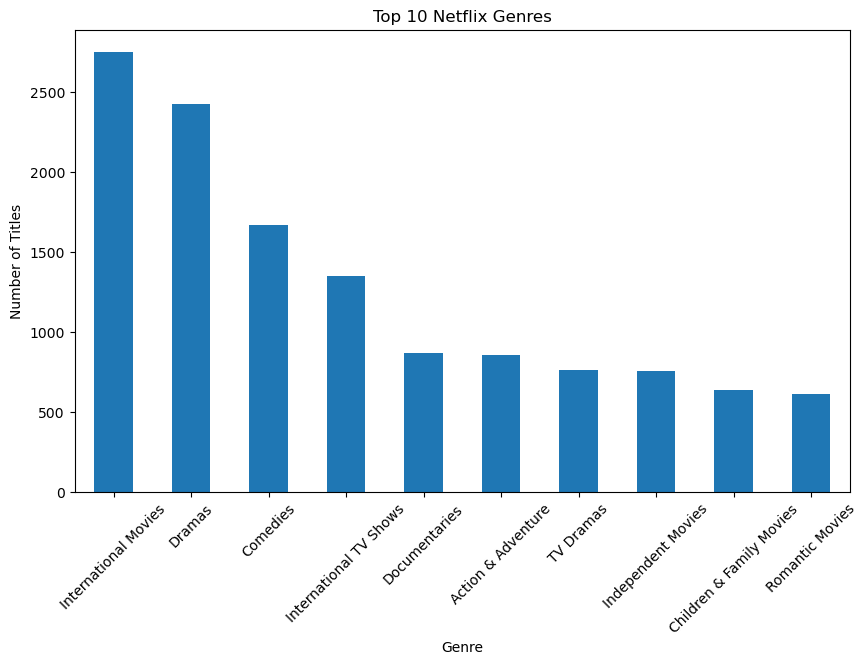

In [35]:
plt.figure(figsize=(10, 6))

genre_counts.head(10).plot(kind='bar')

plt.title('Top 10 Netflix Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

**Interpretation:**  
International Movies are the most common category in the dataset, with 2,752 titles, followed by Dramas with 2,427 titles and Comedies with 1,674 titles. This shows that Netflix's catalog contains a strong presence of international and drama-based content.

### 6.5 Rating Distribution

In [36]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [37]:
df[df['rating'].isin(['74 min', '84 min', '66 min'])][['title', 'type', 'rating', 'duration']]

,title,type,rating,duration
5541,Louis C.K. 2017,Movie,74 min,Unknown
5794,Louis C.K.: Hilarious,Movie,84 min,Unknown
5813,Louis C.K.: Live at the Comedy Store,Movie,66 min,Unknown


In [38]:
mask = df['rating'].isin(['74 min', '84 min', '66 min'])

In [39]:
df.loc[mask, 'duration'] = df.loc[mask, 'rating']

In [40]:
df.loc[mask, 'rating'] = 'unknown'

In [41]:
df.loc[mask, ['title', 'rating', 'duration']]

,title,rating,duration
5541,Louis C.K. 2017,unknown,74 min
5794,Louis C.K.: Hilarious,unknown,84 min
5813,Louis C.K.: Live at the Comedy Store,unknown,66 min


In [42]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [43]:
df['rating'] = df['rating'].replace('unknow', 'unknown')

In [44]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

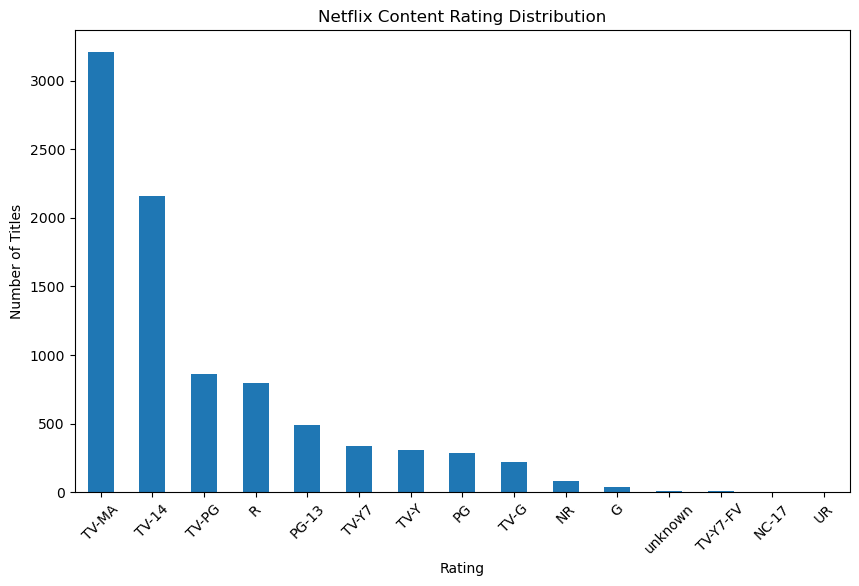

In [45]:
plt.figure(figsize=(10, 6))

df['rating'].value_counts().plot(kind='bar')

plt.title('Netflix Content Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

**Interpretation:**  
TV-MA is the most common content rating in the Netflix dataset, followed by TV-14 and TV-PG. This indicates that a large portion of the catalog is intended for mature or older audiences.

In [46]:
df[df['type'] == 'Movie']

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016-03-09,2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,2016.0
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0


### 6.6 Duration Analysis

In [47]:
movies = ...

In [48]:
movies = df[df['type'] == 'Movie']

In [49]:
movies = df[df['type'] == 'Movie'].copy()

In [50]:
movies['duration_minutes'] = (
    movies['duration']
    .str.replace(' min', '', regex=False)
    .replace('Unknown', None)
    .astype(float)
)

In [51]:
movies[['duration', 'duration_minutes']].head(10)

,duration,duration_minutes
0,90 min,90.0
6,91 min,91.0
7,125 min,125.0
9,104 min,104.0
12,127 min,127.0
13,91 min,91.0
16,67 min,67.0
18,94 min,94.0
22,161 min,161.0
23,61 min,61.0


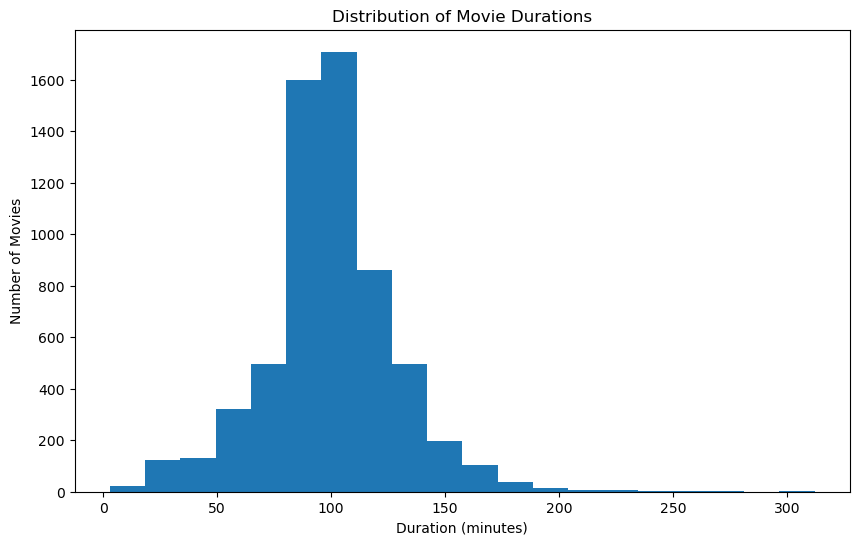

In [52]:
plt.figure(figsize=(10, 6))

plt.hist(movies['duration_minutes'].dropna(), bins=20)

plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')

plt.show()

**Interpretation:**  
The distribution shows that Netflix movies have a wide range of running times, with most movies concentrated around typical feature-film durations. A smaller number of movies have very short or very long running times.

In [53]:
movies = df[df['type'] == 'Movie'].copy()

In [54]:
movies['duration_minutes'] = (
    movies['duration']
    .str.replace(' min', '', regex=False)
    .replace('Unknown', None)
    .astype(float)
)

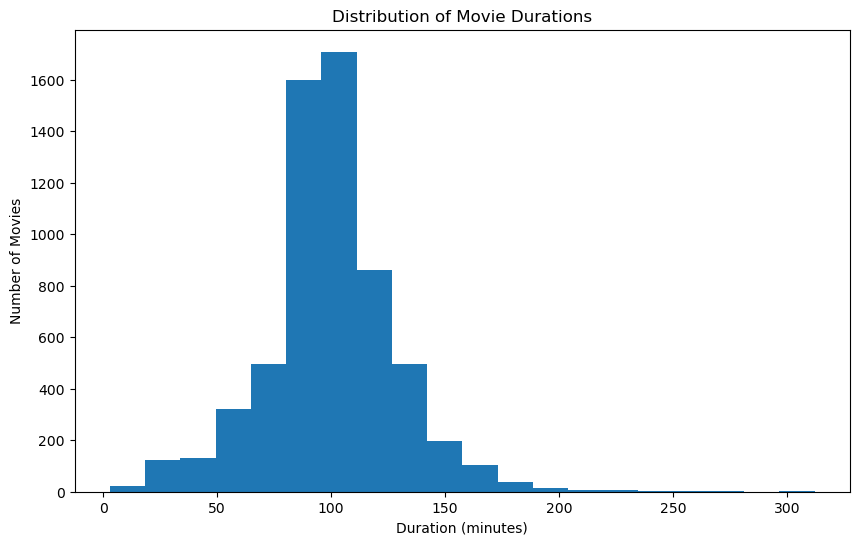

In [55]:
plt.figure(figsize=(10, 6))

plt.hist(movies['duration_minutes'].dropna(), bins=20)

plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')

plt.show()

**Interpretation:**  
The histogram shows that Netflix movies have a wide range of running times. Most movies are concentrated around common feature-film durations, while relatively fewer movies have very short or very long running times.

In [56]:
tv_shows = df[df['type'] == 'TV Show'].copy()

In [57]:
tv_shows['seasons'] = (
    tv_shows['duration']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

In [58]:
tv_shows[['duration', 'seasons']].head(10)

,duration,seasons
1,2 Seasons,2.0
2,1 Season,1.0
3,1 Season,1.0
4,2 Seasons,2.0
5,1 Season,1.0
8,9 Seasons,9.0
10,1 Season,1.0
11,1 Season,1.0
14,1 Season,1.0
15,4 Seasons,4.0


In [59]:
tv_shows['seasons'].value_counts().sort_index()

seasons
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: count, dtype: int64

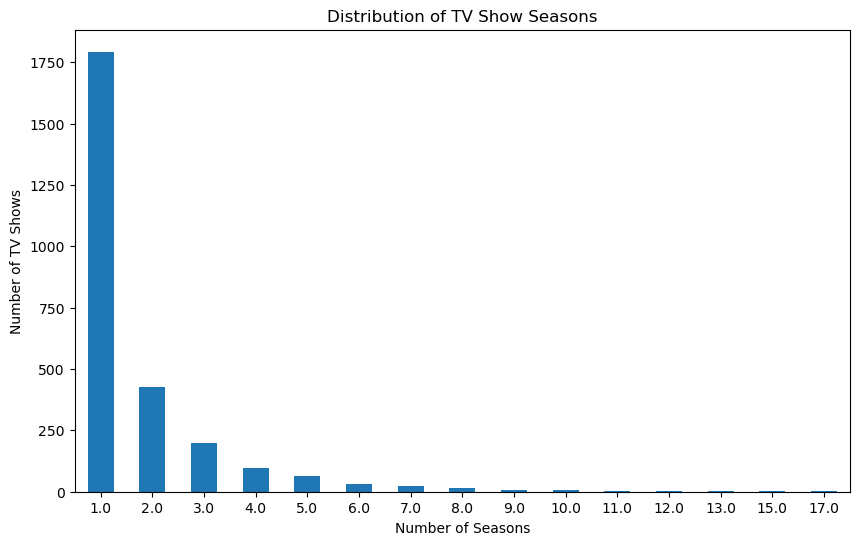

In [60]:
plt.figure(figsize=(10, 6))

tv_shows['seasons'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.xticks(rotation=0)

plt.show()

**Interpretation:**  
The TV Show season distribution is strongly concentrated around shorter series. In the dataset, 1-season TV Shows are the most common, with 1,793 titles, followed by 2-season shows with 425 titles and 3-season shows with 199 titles. The number of titles decreases as the number of seasons increases, indicating that shorter TV series are much more common than long-running series.

### 6.7 Director Analysis

In [61]:
director_counts = df['director'].str.split(', ').explode().value_counts()

In [62]:
director_counts = director_counts[director_counts.index != 'unknown']

In [63]:
director_counts.index != 'unknown'

array([ True,  True,  True, ...,  True,  True,  True])

In [64]:
top_directors = director_counts.head(10)

In [65]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,2021.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0


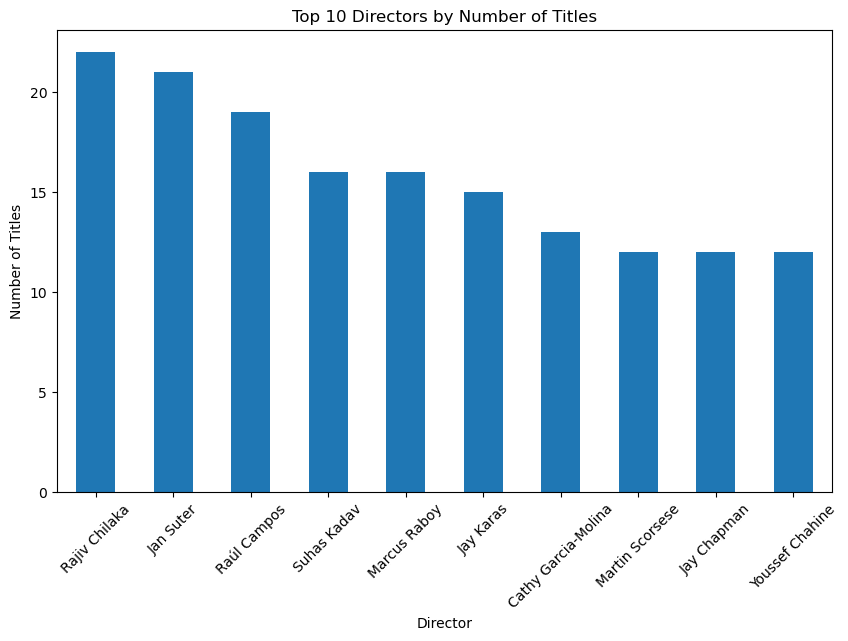

In [66]:
plt.figure(figsize=(10, 6))

top_directors.plot(kind='bar')

plt.title('Top 10 Directors by Number of Titles')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

**Interpretation:**  
Rajiv Chilaka has the highest number of titles among the directors in the Netflix dataset. The remaining directors in the top 10 have progressively fewer titles, showing that content production is distributed across many directors, while a small group of directors contribute multiple titles to the catalog. The presence of directors with several titles also suggests that Netflix's catalog includes recurring collaborations with certain content creators.

## 7. Business Insights

**Business Insight 1:**  
Netflix's content additions increased strongly from 2015 and reached a peak in 2019, after which the number of titles added declined through 2021. This suggests that the rate of catalog expansion was not constant, so content acquisition and release planning may need to account for changing yearly addition patterns.

**Business Insight 2:**  
Netflix's catalog has strong representation across multiple content categories, with International Movies, Dramas, and Comedies among the most frequently occurring categories. This indicates that maintaining a diverse mix of genres can be important when building a broad content library for different audience preferences.

df['is_indian'].value_counts()

In [67]:
indian_titles = df['country'].str.contains('India', na=False).sum()
total_titles = len(df)

print(f"India is associated with {indian_titles} out of {total_titles} titles, which is approximately {(indian_titles / total_titles) * 100:.1f}% of the catalog.")

India is associated with 1046 out of 8807 titles, which is approximately 11.9% of the catalog.


**Business Insight 3:**  
India is associated with 1,046 titles in the Netflix dataset, representing approximately 11.9% of the catalog. This shows that Indian content has a significant presence in the dataset and highlights India as an important content market for Netflix.

**Business Insight 4:**  
TV-MA and TV-14 are the two most common ratings in the Netflix dataset, with 3,207 and 2,160 titles respectively. This indicates that a large portion of the catalog is targeted toward mature and teenage audiences, which can be useful when considering audience targeting and content acquisition strategies.

**Business Insight 5:**  
The TV Show catalog is strongly concentrated around shorter series. One-season shows account for 1,793 titles, while the number of titles decreases substantially as the number of seasons increases. This suggests that shorter-format series are much more prevalent in the Netflix catalog than long-running shows, which can be considered when planning future series content.

## 8. Feature Engineering

### 8.1 Content Age

In [68]:
df['content_age'] = 2021 - df['release_year']

In [69]:
df[['release_year', 'content_age']].head()

,release_year,content_age
0,2020,1
1,2021,0
2,2021,0
3,2021,0
4,2021,0


### 8.2 Genre Count

In [70]:
df['genre_count'] = df['listed_in'].str.split(', ').str.len()

In [71]:
df[['listed_in', 'genre_count']].head()

,listed_in,genre_count
0,Documentaries,1
1,"International TV Shows, TV Dramas, TV Mysteries",3
2,"Crime TV Shows, International TV Shows, TV Act...",3
3,"Docuseries, Reality TV",2
4,"International TV Shows, Romantic TV Shows, TV ...",3


### 8.3 Is Indian

In [72]:
df['is_indian'] = df['country'].str.contains('India', na=False).astype(int)

In [73]:
df[['country', 'is_indian']].head(10)

,country,is_indian
0,United States,0
1,South Africa,0
2,unknown,0
3,unknown,0
4,India,1
5,unknown,0
6,unknown,0
7,"United States, Ghana, Burkina Faso, United Kin...",0
8,United Kingdom,0
9,United States,0


In [74]:
ml_data = df[['content_age', 'genre_count', 'is_indian', 'rating', 'type']].copy()

In [75]:
ml_data = pd.get_dummies(ml_data, columns=['rating'], dtype=int)

In [76]:
ml_data.head()

,content_age,genre_count,is_indian,type,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR,rating_unknown
0,1,1,0,Movie,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,3,0,TV Show,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,0,3,0,TV Show,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,0,2,0,TV Show,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0,3,1,TV Show,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [77]:
ml_data['type'] = ml_data['type'].map({'Movie': 0, 'TV Show': 1})

In [78]:
ml_data.head()

,content_age,genre_count,is_indian,type,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR,rating_unknown
0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,3,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,0,3,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,0,2,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0,3,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


### Groupby and Aggregation

The dataset is grouped by content type (Movie and TV Show) to compare the total number of titles, average content age, and average number of genres. The agg() function is used to calculate multiple summary statistics for each content type.



In [79]:
df.groupby('type').agg(
    total_titles=('show_id', 'count'),
    average_release_year=('release_year', 'mean')
)

,total_titles,average_release_year
type,,
Movie,6131,2013.121514
TV Show,2676,2016.605755


## 9. Machine Learning

### 9.1 Preparing Features

In [80]:
X = ml_data.drop('type', axis=1)
y = ml_data['type']

In [81]:
X = ml_data.drop('type', axis=1)

In [82]:
y = ml_data['type']

In [83]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8807, 18)
y shape: (8807,)


In [84]:
ml_data = df[['content_age', 'genre_count', 'is_indian', 'rating', 'type']].copy()

### 9.2 Train-Test Split

In [85]:
from sklearn.model_selection import train_test_split

X = ml_data.drop('type', axis=1)
y = ml_data['type']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
ml_data.head()

,content_age,genre_count,is_indian,rating,type
0,1,1,0,PG-13,Movie
1,0,3,0,TV-MA,TV Show
2,0,3,0,TV-MA,TV Show
3,0,2,0,TV-MA,TV Show
4,0,3,1,TV-MA,TV Show


In [87]:
ml_data = pd.get_dummies(ml_data, columns=['rating'], dtype=int)

In [88]:
ml_data.head()

,content_age,genre_count,is_indian,type,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR,rating_unknown
0,1,1,0,Movie,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,3,0,TV Show,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,0,3,0,TV Show,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,0,2,0,TV Show,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0,3,1,TV Show,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [89]:
ml_data['type'] = ml_data['type'].map({
    'Movie': 0,
    'TV Show': 1
})

In [90]:
ml_data['type'].value_counts()

type
0    6131
1    2676
Name: count, dtype: int64

In [91]:
X = ml_data.drop('type', axis=1)
y = ml_data['type']

In [92]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8807, 18)
y shape: (8807,)


In [93]:
from sklearn.model_selection import train_test_split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 9.3 Feature Scaling

In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
print(X.isna().sum())

content_age        0
genre_count        0
is_indian          0
rating_G           0
rating_NC-17       0
rating_NR          0
rating_PG          0
rating_PG-13       0
rating_R           0
rating_TV-14       0
rating_TV-G        0
rating_TV-MA       0
rating_TV-PG       0
rating_TV-Y        0
rating_TV-Y7       0
rating_TV-Y7-FV    0
rating_UR          0
rating_unknown     0
dtype: int64


In [97]:
print(y.isna().sum())

0


In [98]:
print(ml_data['type'].unique())

[0 1]


In [99]:
ml_data = df[['content_age', 'genre_count', 'is_indian', 'rating', 'type']].copy()

In [100]:
print(ml_data['type'].unique())

['Movie' 'TV Show']


In [101]:
ml_data['type'] = ml_data['type'].map({
    'Movie': 0,
    'TV Show': 1
})

In [102]:
print(ml_data['type'].unique())
print(ml_data['type'].isna().sum())

[0 1]
0


In [103]:
ml_data = pd.get_dummies(ml_data, columns=['rating'], dtype=int)

In [104]:
ml_data.head()

,content_age,genre_count,is_indian,type,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR,rating_unknown
0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,3,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,0,3,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,0,2,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0,3,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [105]:
X = ml_data.drop('type', axis=1)
y = ml_data['type']

In [106]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8807, 18)
y shape: (8807,)


In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [108]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7045, 18)
Testing data: (1762, 18)


### 9.4 Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

In [109]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [110]:
from sklearn.linear_model import LogisticRegression

In [111]:
log_model = LogisticRegression(max_iter=1000, random_state=42)

In [112]:
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [113]:
y_pred_log = log_model.predict(X_test_scaled)

In [114]:
print(y_pred_log[:10])

[0 0 0 0 0 1 1 1 0 0]


In [115]:
from sklearn.metrics import accuracy_score, f1_score

accuracy_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", accuracy_log)
print("Logistic Regression F1 Score:", f1_log)

Logistic Regression Accuracy: 0.7162315550510783
Logistic Regression F1 Score: 0.4075829383886256


### 9.5 Decision Tree

In [116]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

### 9.6 Model Evaluation

In [117]:
y_pred_tree = tree_model.predict(X_test)

print(y_pred_tree[:10])

[0 0 0 0 0 0 1 0 1 0]


In [118]:
from sklearn.metrics import accuracy_score, f1_score

accuracy_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)
print("Decision Tree F1 Score:", f1_tree)

Decision Tree Accuracy: 0.7162315550510783
Decision Tree F1 Score: 0.37185929648241206


### 9.7 Model Comparison

In [119]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_log, accuracy_tree],
    'F1 Score': [f1_log, f1_tree]
})

comparison

,Model,Accuracy,F1 Score
0,Logistic Regression,0.716232,0.407583
1,Decision Tree,0.716232,0.371859


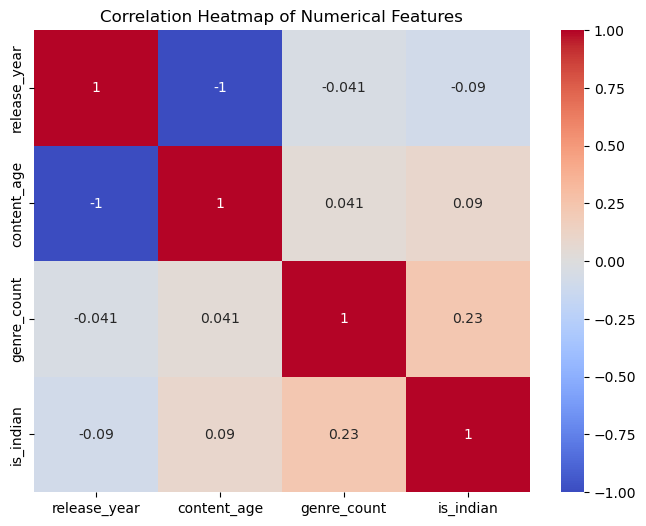

In [120]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['release_year', 'content_age', 'genre_count', 'is_indian']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [121]:
import matplotlib.pyplot as plt

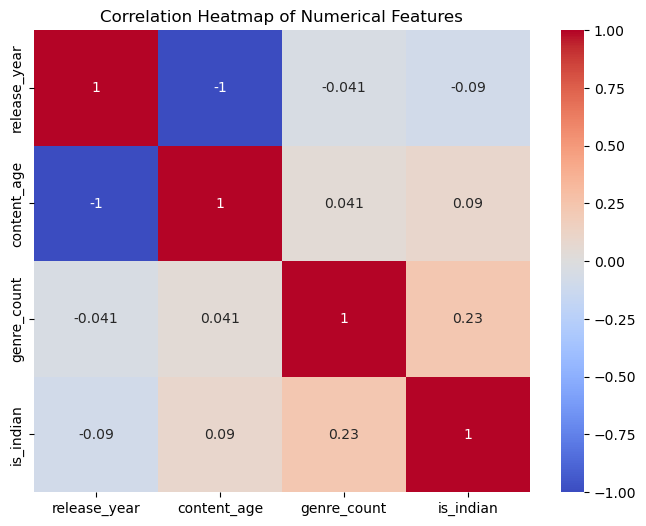

In [122]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[['release_year', 'content_age', 'genre_count', 'is_indian']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Correlation Heatmap Insights

The correlation heatmap shows the relationships between the numerical features used in the analysis. `content_age` is strongly related to `release_year` because content age is derived from release year. The engineered features `genre_count` and `is_indian` show weaker relationships with the other numerical features, indicating that they provide additional information rather than simply duplicating the same variable.

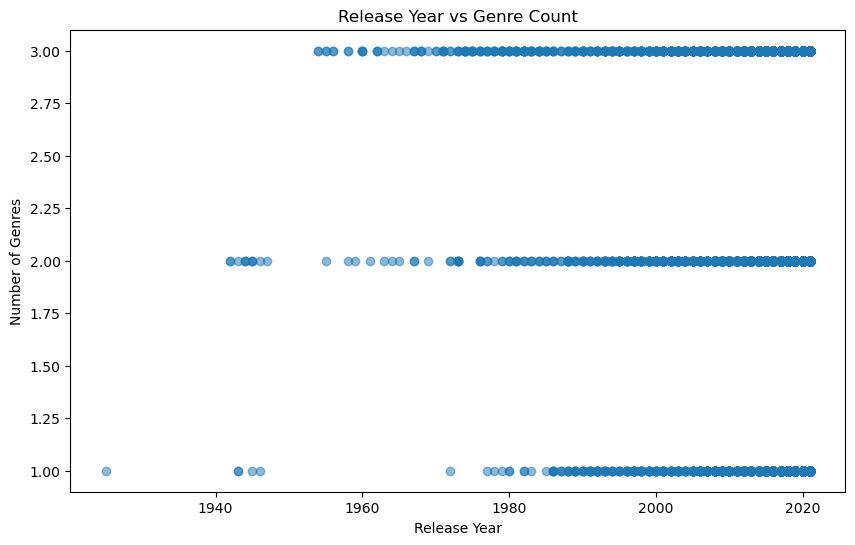

In [123]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['release_year'],
    df['genre_count'],
    alpha=0.5
)

plt.title('Release Year vs Genre Count')
plt.xlabel('Release Year')
plt.ylabel('Number of Genres')
plt.show()

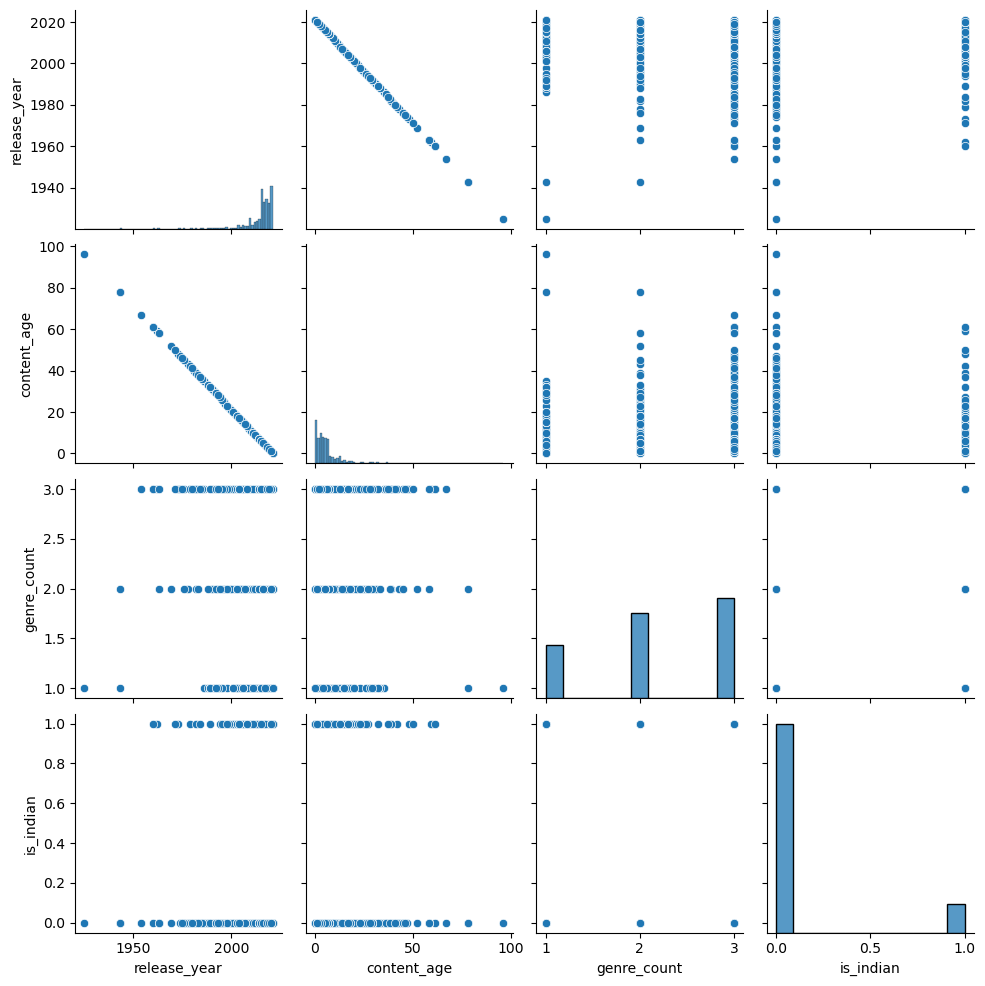

In [124]:
sample_df = df[
    ['release_year', 'content_age', 'genre_count', 'is_indian']
].sample(1000, random_state=42)

sns.pairplot(sample_df)

plt.show()

In [125]:
comparison

,Model,Accuracy,F1 Score
0,Logistic Regression,0.716232,0.407583
1,Decision Tree,0.716232,0.371859


## Actionable Recommendations

1. Netflix should continue investing in international content and expand region-specific content strategies, as international titles represent a major part of the catalog and can help serve diverse audiences.

2. Netflix should maintain a strong focus on movies while continuing to expand TV Show content, as movies currently form the majority of the catalog while TV Shows show strong growth.

3. Netflix should consider audience-focused content planning, particularly for mature and teenage audiences, because TV-MA and TV-14 are the most common ratings in the dataset.

## Conclusion

This project analyzed Netflix Movies and TV Shows using exploratory data analysis, visualization, feature engineering, and machine learning. The analysis showed that Movies form the majority of the Netflix catalog, while TV Shows have shown strong growth over the years. Content additions increased significantly after 2015 and reached their highest level in 2019. International Movies and Dramas were among the most common content categories, while TV-MA and TV-14 were the most common ratings.

Feature engineering was performed by creating content_age, genre_count, and is_indian. These features were then used along with encoded rating information to build classification models for predicting whether a title is a Movie or TV Show.

Two classification models were evaluated: Logistic Regression and Decision Tree. Both achieved an accuracy of 71.62%. Logistic Regression achieved a higher F1 Score of 0.408 compared with 0.372 for the Decision Tree, making it the better-performing model among the two based on F1 Score.

Overall, the project demonstrates how exploratory data analysis, feature engineering, visualization, and machine learning can be used together to understand Netflix's content catalog and support content strategy decisions.